# Homework 09: Finetuning GPT

Refer to the corresponding lab and Rashcka's book (Ch. 6 and 7)



---
## Exercises

**Exercise 1 — Temperature exploration**

Run `generate()` on the same prompt with temperatures `[0.0, 0.5, 1.0, 1.5, 2.0]` and `top_k=20`. Print each output. At what temperature does the text start becoming incoherent for your trained model?

In [3]:
# ── SETUP 1/3: imports, tokenizer, device, and the GPT model classes ─────────
# Copied from the corresponding lab (09_Decoding_Finetuning.ipynb) so this
# homework is self-contained on Colab. Run this cell FIRST.
!pip install torch tiktoken --quiet

import torch, torch.nn as nn, tiktoken, urllib.request, json, time
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from matplotlib.ticker import MaxNLocator

# GPT-2 byte-pair tokenizer + pick GPU if available (the T4 on Colab)
tokenizer = tiktoken.get_encoding("gpt2")
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── Model building blocks ─────────────────────────────────────────────────────
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var  = x.var(dim=-1, keepdim=True, unbiased=False)
        return self.scale * (x - mean) / torch.sqrt(var + self.eps) + self.shift

class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * x**3)))

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]))
    def forward(self, x): return self.layers(x)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = d_out // num_heads
        self.d_out     = d_out
        self.W_query   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key     = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj  = nn.Linear(d_out, d_out)
        self.dropout   = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))
    def forward(self, x):
        b, n, _ = x.shape
        q = self.W_query(x).view(b, n, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.W_key(x).view(b, n, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.W_value(x).view(b, n, self.num_heads, self.head_dim).transpose(1, 2)
        scores = q @ k.transpose(2, 3)
        scores.masked_fill_(self.mask.bool()[:n, :n], -torch.inf)
        w = self.dropout(torch.softmax(scores / k.shape[-1]**0.5, dim=-1))
        return self.out_proj((w @ v).transpose(1, 2).contiguous().view(b, n, self.d_out))

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att  = MultiHeadAttention(cfg["emb_dim"], cfg["emb_dim"],
                                        cfg["context_length"], cfg["drop_rate"],
                                        cfg["n_heads"], cfg["qkv_bias"])
        self.ff   = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop  = nn.Dropout(cfg["drop_rate"])
    def forward(self, x):
        x = x + self.drop(self.att(self.norm1(x)))
        x = x + self.drop(self.ff(self.norm2(x)))
        return x

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb   = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb   = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb  = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head   = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)
    def forward(self, in_idx):
        b, n = in_idx.shape
        x = self.tok_emb(in_idx) + self.pos_emb(torch.arange(n, device=in_idx.device))
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        return self.out_head(self.final_norm(x))

# ── Utility functions: text <-> token id tensors ─────────────────────────────
def text_to_token_ids(text, tokenizer):
    return torch.tensor(tokenizer.encode(text, allowed_special={"<|endoftext|>"})).unsqueeze(0)

def token_ids_to_text(token_ids, tokenizer):
    return tokenizer.decode(token_ids.squeeze(0).tolist())

print("All classes loaded ✓")

Device: cuda
All classes loaded ✓


In [4]:
# ── SETUP 2/3: decoding function used by the exercises ───────────────────────
# Defines `generate` (temperature + top-k sampling). Copied from lab 09.
def generate(model, idx, max_new_tokens, context_size,
             temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits = model(idx[:, -context_size:])[:, -1, :]

        # Top-k filter: keep only the k highest-probability tokens
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            logits = torch.where(
                logits < top_logits[:, -1],
                torch.tensor(float("-inf")).to(logits.device),
                logits
            )

        # Temperature scaling + sampling; temperature == 0 means greedy argmax
        if temperature > 0.0:
            probs    = torch.softmax(logits / temperature, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        # Optional early stop at the end-of-text token
        if eos_id is not None and idx_next.item() == eos_id:
            break

        idx = torch.cat((idx, idx_next), dim=1)
    return idx

In [5]:
# ── SETUP 3/3: load (or quickly train) the model used by the exercises ───────
# Defines GPT_CONFIG_TRAIN, `model`. Copied from lab 09_Decoding_Finetuning.
# On a fresh Colab with no saved checkpoint this trains a tiny model on
# "The Verdict" (~5 min on CPU, faster on the T4 GPU) and caches it.
GPT_CONFIG_TRAIN = {
    "vocab_size": 50257, "context_length": 256,
    "emb_dim": 768, "n_heads": 12, "n_layers": 12,
    "drop_rate": 0.1, "qkv_bias": False
}

# Download "The Verdict" training text if we don't already have it locally
import os
if not os.path.exists("the-verdict.txt"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/"
        "main/ch02/01_main-chapter-code/the-verdict.txt",
        "the-verdict.txt"
    )

with open("the-verdict.txt", encoding="utf-8") as f:
    text_data = f.read()

# If no saved weights exist, train a small model from scratch; otherwise load it
if not os.path.exists("gpt_verdict.pth"):
    print("No saved model found — training a quick one (≈5 min on CPU)...")

    class GPTDatasetV1(Dataset):
        def __init__(self, txt, tokenizer, max_length, stride):
            self.input_ids, self.target_ids = [], []
            ids = tokenizer.encode(txt)
            for i in range(0, len(ids) - max_length, stride):
                self.input_ids.append(torch.tensor(ids[i:i+max_length]))
                self.target_ids.append(torch.tensor(ids[i+1:i+max_length+1]))
        def __len__(self): return len(self.input_ids)
        def __getitem__(self, idx): return self.input_ids[idx], self.target_ids[idx]

    ctx = GPT_CONFIG_TRAIN["context_length"]
    split = int(0.9 * len(text_data))
    train_loader = DataLoader(GPTDatasetV1(text_data[:split], tokenizer, ctx, ctx),
                              batch_size=2, shuffle=True, drop_last=True)
    val_loader   = DataLoader(GPTDatasetV1(text_data[split:], tokenizer, ctx, ctx),
                              batch_size=2, shuffle=False, drop_last=False)

    def calc_loss_batch(xb, yb, model, device):
        xb, yb = xb.to(device), yb.to(device)
        return torch.nn.functional.cross_entropy(model(xb).flatten(0,1), yb.flatten())

    torch.manual_seed(123)
    model = GPTModel(GPT_CONFIG_TRAIN).to(device)
    opt   = torch.optim.AdamW(model.parameters(), lr=4e-4, weight_decay=0.1)
    for epoch in range(10):
        model.train()
        for xb, yb in train_loader:
            opt.zero_grad(); calc_loss_batch(xb, yb, model, device).backward(); opt.step()
        print(f"Epoch {epoch+1}/10 done")
    torch.save(model.state_dict(), "gpt_verdict.pth")
    print("Saved to gpt_verdict.pth")
else:
    model = GPTModel(GPT_CONFIG_TRAIN)
    model.load_state_dict(torch.load("gpt_verdict.pth", map_location=device))
    model.to(device)
    print("Loaded saved model ✓")

model.eval()

Loaded saved model ✓


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out

In [6]:
# Your code here
prompt = "The Supreme Court held that"
for T in [0.0, 0.5, 1.0, 1.5, 2.0]:
    torch.manual_seed(42)
    out = generate(model, text_to_token_ids(prompt, tokenizer).to(device),
                   max_new_tokens=25, context_size=GPT_CONFIG_TRAIN["context_length"],
                   temperature=T, top_k=20)
    print(f"τ={T}: {token_ids_to_text(out, tokenizer)}")

τ=0.0: The Supreme Court held that he was not that my hostess was "interesting": on that Mrs. "Yes--and by me to me to have
τ=0.5: The Supreme Court held that he was not that the picture for a smile that lifted the frame. "There: "Gisburn! The women had
τ=1.0: The Supreme Court held that he was no that the picture for a smile that and uncertain. It was his part till I forced--the fact, the
τ=1.5: The Supreme Court held that he was no that the picture for a t arm-room his last word it all till I forced with the end women had
τ=2.0: The Supreme Court held that he was no that the latter his eyes: arm and uncertain his last word it all till I forced with my wonder women say


**Exercise 2 — Instruction masking**

Currently our `custom_collate_fn` only masks *padding* tokens with `-100`. An alternative is to also mask the instruction tokens, so the model **only learns to predict the response** (not the prompt).

Modify `custom_collate_fn` to additionally set all instruction tokens to `-100` in the targets. Use `format_input(entry)` to determine how many tokens to mask.

Does this improve or hurt performance? Why might it help (less overfitting to the instruction format) or hurt (less signal)?

In [9]:
# ── Exercise 2: Instruction masking ──────────────────────────────────────────
# First bring in the instruction-tuning pieces from the lab so this exercise is
# self-contained: the dataset, the Alpaca prompt formatter, and a train/val/test
# split. (Same as 09_Decoding_Finetuning.)
import os, json, urllib.request
from functools import partial

# Download the instruction dataset (~1.1k instruction / input / output examples)
if not os.path.exists("instruction-data.json"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
        "/main/ch07/01_main-chapter-code/instruction-data.json",
        "instruction-data.json"
    )
with open("instruction-data.json") as f:
    data = json.load(f)

def format_input(entry):
    """Wrap an instruction entry in the Alpaca prompt template (instruction + optional input)."""
    instruction_text = (
        "Below is an instruction that describes a task. "
        "Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    return instruction_text + input_text

# 85 / 5 / 10 split (same proportions as the lab)
train_portion = int(len(data) * 0.85)
test_portion  = int(len(data) * 0.10)
train_data = data[:train_portion]
test_data  = data[train_portion:train_portion + test_portion]
val_data   = data[train_portion + test_portion:]


# ── The modification ─────────────────────────────────────────────────────────
# To mask the instruction we need to know, per example, WHERE the response
# begins. So the dataset stores (encoded_full_text, instruction_len), where
# instruction_len is the token count of everything up to and including
# "### Response:\n" -- i.e. format_input(entry) + the response header.
class InstructionDatasetWithMask(Dataset):
    def __init__(self, data, tokenizer):
        self.items = []
        for entry in data:
            instruction_part = format_input(entry) + "\n\n### Response:\n"
            full_text        = instruction_part + entry["output"]
            encoded_full     = tokenizer.encode(full_text)
            instruction_len  = len(tokenizer.encode(instruction_part))
            self.items.append((encoded_full, instruction_len))
    def __len__(self):  return len(self.items)
    def __getitem__(self, idx): return self.items[idx]


def custom_collate_fn(batch, pad_token_id=50256, ignore_index=-100,
                      allowed_max_length=None, device="cpu"):
    """Lab collate fn + instruction masking.

    Each batch item is (token_ids, instruction_len). In addition to masking
    padding, we set the instruction tokens in the *targets* to -100 so the
    cross-entropy loss (which uses ignore_index=-100) is computed ONLY over the
    response tokens.
    """
    max_len = max(len(ids) + 1 for ids, _ in batch)   # +1 for the input/target shift
    inputs_lst, targets_lst = [], []

    for ids, instruction_len in batch:
        padded  = ids + [pad_token_id] * (max_len - len(ids))
        inputs  = torch.tensor(padded[:-1])   # drop last  -> inputs
        targets = torch.tensor(padded[1:])    # shift by 1 -> targets

        # (1) original behaviour: keep ONE end-of-text/pad token, mask the rest
        pad_positions = (targets == pad_token_id).nonzero().squeeze(-1)
        if pad_positions.numel() > 1:
            targets[pad_positions[1:]] = ignore_index

        # (2) NEW: mask the instruction tokens. Targets are shifted by one, so
        #     the first RESPONSE token sits at target index (instruction_len - 1).
        #     Everything before that index is the prompt -> set it to -100.
        targets[:instruction_len - 1] = ignore_index

        if allowed_max_length:
            inputs  = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs); targets_lst.append(targets)

    return torch.stack(inputs_lst).to(device), torch.stack(targets_lst).to(device)


# ── Verify the masking on a tiny batch ───────────────────────────────────────
demo_ds      = InstructionDatasetWithMask(train_data[:2], tokenizer)
demo_collate = partial(custom_collate_fn, device="cpu", allowed_max_length=1024)
inp, tgt     = demo_collate([demo_ds[0], demo_ds[1]])

ids0, inst_len0 = demo_ds[0]
print(f"Example 0: {len(ids0)} tokens total, {inst_len0} instruction tokens")
print("First 12 target values (note the -100s masking the instruction):")
print(tgt[0][:12])
n_masked = (tgt[0] == -100).sum().item()
print(f"Masked targets in example 0: {n_masked} "
      f"(= {inst_len0 - 1} instruction + the rest padding)")
print("\nTo train with this, swap InstructionDatasetWithMask + this collate fn "
      "into the lab's DataLoaders and reuse train_instruction_model() unchanged "
      "(it already passes ignore_index=-100 to cross_entropy).")

Example 0: 74 tokens total, 54 instruction tokens
First 12 target values (note the -100s masking the instruction):
tensor([-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100])
Masked targets in example 0: 53 (= 53 instruction + the rest padding)

To train with this, swap InstructionDatasetWithMask + this collate fn into the lab's DataLoaders and reuse train_instruction_model() unchanged (it already passes ignore_index=-100 to cross_entropy).


In [10]:
# ── Load pretrained GPT-2 Medium (355M) to fine-tune ─────────────────────────
# Grab Raschka's helper that downloads OpenAI's pretrained GPT-2 weights.
import numpy as np
if not os.path.exists("gpt_download.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/"
        "main/ch05/01_main-chapter-code/gpt_download.py",
        "gpt_download.py"
    )
from gpt_download import download_and_load_gpt2

def load_weights_into_gpt(gpt, params):
    """Copy OpenAI's TensorFlow GPT-2 weights into our PyTorch GPTModel."""
    gpt.pos_emb.weight = nn.Parameter(torch.tensor(params["wpe"]))
    gpt.tok_emb.weight = nn.Parameter(torch.tensor(params["wte"]))
    for b, block in enumerate(gpt.trf_blocks):
        # attention: the OpenAI checkpoint stores Q,K,V stacked -> split into 3
        q, k, v = np.split(params["blocks"][b]["attn"]["c_attn"]["w"], 3, axis=-1)
        block.att.W_query.weight = nn.Parameter(torch.tensor(q).T)
        block.att.W_key.weight   = nn.Parameter(torch.tensor(k).T)
        block.att.W_value.weight = nn.Parameter(torch.tensor(v).T)
        q_b, k_b, v_b = np.split(params["blocks"][b]["attn"]["c_attn"]["b"], 3)
        block.att.W_query.bias = nn.Parameter(torch.tensor(q_b))
        block.att.W_key.bias   = nn.Parameter(torch.tensor(k_b))
        block.att.W_value.bias = nn.Parameter(torch.tensor(v_b))
        block.att.out_proj.weight = nn.Parameter(torch.tensor(params["blocks"][b]["attn"]["c_proj"]["w"]).T)
        block.att.out_proj.bias   = nn.Parameter(torch.tensor(params["blocks"][b]["attn"]["c_proj"]["b"]))
        block.ff.layers[0].weight = nn.Parameter(torch.tensor(params["blocks"][b]["mlp"]["c_fc"]["w"]).T)
        block.ff.layers[0].bias   = nn.Parameter(torch.tensor(params["blocks"][b]["mlp"]["c_fc"]["b"]))
        block.ff.layers[2].weight = nn.Parameter(torch.tensor(params["blocks"][b]["mlp"]["c_proj"]["w"]).T)
        block.ff.layers[2].bias   = nn.Parameter(torch.tensor(params["blocks"][b]["mlp"]["c_proj"]["b"]))
        block.norm1.scale = nn.Parameter(torch.tensor(params["blocks"][b]["ln_1"]["g"]))
        block.norm1.shift = nn.Parameter(torch.tensor(params["blocks"][b]["ln_1"]["b"]))
        block.norm2.scale = nn.Parameter(torch.tensor(params["blocks"][b]["ln_2"]["g"]))
        block.norm2.shift = nn.Parameter(torch.tensor(params["blocks"][b]["ln_2"]["b"]))
    gpt.final_norm.scale = nn.Parameter(torch.tensor(params["g"]))
    gpt.final_norm.shift = nn.Parameter(torch.tensor(params["b"]))
    gpt.out_head.weight  = nn.Parameter(torch.tensor(params["wte"]))  # tied to token embedding

# GPT-2 Medium config (dropout off + qkv bias on, as OpenAI's weights expect)
INS_CONFIG = {
    "vocab_size": 50257, "context_length": 1024,
    "emb_dim": 1024, "n_heads": 16, "n_layers": 24,   # Medium
    "drop_rate": 0.0, "qkv_bias": True
}
# NOTE: if the T4 runs out of memory, switch to the 124M model instead:
#   INS_CONFIG = {**GPT_CONFIG_TRAIN, "context_length":1024, "drop_rate":0.0, "qkv_bias":True}
#   download_and_load_gpt2(model_size="124M", ...)

settings_m, params_m = download_and_load_gpt2(model_size="355M", models_dir="gpt2")
ins_model = GPTModel(INS_CONFIG)
load_weights_into_gpt(ins_model, params_m)
ins_model.eval()
print("GPT-2 Medium (355M) loaded ✓")

File already exists and is up-to-date: gpt2/355M/checkpoint
File already exists and is up-to-date: gpt2/355M/encoder.json
File already exists and is up-to-date: gpt2/355M/hparams.json
File already exists and is up-to-date: gpt2/355M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/355M/model.ckpt.index
File already exists and is up-to-date: gpt2/355M/model.ckpt.meta
File already exists and is up-to-date: gpt2/355M/vocab.bpe
GPT-2 Medium (355M) loaded ✓


In [11]:
# ── Build instruction-MASKED DataLoaders and fine-tune ───────────────────────
# Reuses InstructionDatasetWithMask + the masked custom_collate_fn from Exercise 2.
customized_collate = partial(custom_collate_fn, device=device, allowed_max_length=1024)

train_ins_ds = InstructionDatasetWithMask(train_data, tokenizer)
val_ins_ds   = InstructionDatasetWithMask(val_data,   tokenizer)

train_ins_loader = DataLoader(train_ins_ds, batch_size=8, shuffle=True,
                               drop_last=True,  collate_fn=customized_collate)
val_ins_loader   = DataLoader(val_ins_ds,   batch_size=8, shuffle=False,
                               drop_last=False, collate_fn=customized_collate)

# Average cross-entropy over a few batches; ignore_index=-100 skips masked tokens
def calc_loss_loader_ins(loader, model, device, num_batches=None):
    total, n = 0., min(num_batches or len(loader), len(loader))
    for i, (xb, yb) in enumerate(loader):
        if i >= n: break
        xb, yb = xb.to(device), yb.to(device)
        total += torch.nn.functional.cross_entropy(
            model(xb).flatten(0, 1), yb.flatten(), ignore_index=-100
        ).item()
    return total / n

# Training loop (from lab): evaluates periodically and prints a sample answer per epoch
def train_instruction_model(model, train_loader, val_loader, optimizer,
                            device, num_epochs, eval_freq, eval_iter,
                            val_sample, tokenizer):
    train_losses, val_losses, tokens_seen = [], [], []
    seen, step = 0, -1
    for epoch in range(num_epochs):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            xb, yb = xb.to(device), yb.to(device)
            loss = torch.nn.functional.cross_entropy(
                model(xb).flatten(0, 1), yb.flatten(), ignore_index=-100
            )
            loss.backward(); optimizer.step()
            seen += xb.numel(); step += 1
            if step % eval_freq == 0:
                tl = calc_loss_loader_ins(train_loader, model, device, eval_iter)
                vl = calc_loss_loader_ins(val_loader,   model, device, eval_iter)
                train_losses.append(tl); val_losses.append(vl); tokens_seen.append(seen)
                print(f"Ep {epoch+1} Step {step:04d}: train={tl:.3f}  val={vl:.3f}")
        # show one sample response after each epoch to watch it learn.
        # Feed the prompt INCLUDING the "### Response:\n" header so a masked model
        # (which never learned to emit the header) still produces an answer.
        model.eval()
        prompt = format_input(val_sample) + "\n\n### Response:\n"
        token_ids = generate(model, text_to_token_ids(prompt, tokenizer).to(device),
                             max_new_tokens=80, context_size=INS_CONFIG["context_length"],
                             temperature=0.0, eos_id=50256)
        resp = token_ids_to_text(token_ids, tokenizer)[len(prompt):].strip()
        print(f"  Sample response: {resp[:120]}...")
        model.train()
    return train_losses, val_losses, tokens_seen


# Sanity-check the starting loss, then train (~a few minutes on the T4)
ins_model.to(device)
with torch.no_grad():
    print(f"Initial — train={calc_loss_loader_ins(train_ins_loader, ins_model, device, 5):.3f}  "
          f"val={calc_loss_loader_ins(val_ins_loader, ins_model, device, 5):.3f}")

torch.manual_seed(123)
optimizer_ins = torch.optim.AdamW(ins_model.parameters(), lr=5e-5, weight_decay=0.1)

t0 = time.time()
train_losses_ins, val_losses_ins, tokens_seen_ins = train_instruction_model(
    ins_model, train_ins_loader, val_ins_loader, optimizer_ins, device,
    num_epochs=2, eval_freq=5, eval_iter=5,
    val_sample=val_data[0], tokenizer=tokenizer
)
print(f"\nTraining completed in {(time.time()-t0)/60:.1f} min")

Initial — train=2.898  val=2.835
Ep 1 Step 0000: train=2.027  val=1.932
Ep 1 Step 0005: train=1.443  val=1.382
Ep 1 Step 0010: train=1.228  val=1.307
Ep 1 Step 0015: train=1.249  val=1.262
Ep 1 Step 0020: train=1.168  val=1.239
Ep 1 Step 0025: train=1.015  val=1.212
Ep 1 Step 0030: train=1.148  val=1.188
Ep 1 Step 0035: train=0.935  val=1.165
Ep 1 Step 0040: train=1.111  val=1.170
Ep 1 Step 0045: train=0.821  val=1.155
Ep 1 Step 0050: train=0.923  val=1.120
Ep 1 Step 0055: train=1.197  val=1.134
Ep 1 Step 0060: train=0.949  val=1.140
Ep 1 Step 0065: train=0.773  val=1.082
Ep 1 Step 0070: train=0.768  val=1.081
Ep 1 Step 0075: train=0.765  val=1.073
Ep 1 Step 0080: train=0.801  val=1.065
Ep 1 Step 0085: train=0.686  val=1.067
Ep 1 Step 0090: train=0.729  val=1.053
Ep 1 Step 0095: train=0.594  val=1.038
Ep 1 Step 0100: train=0.707  val=1.018
Ep 1 Step 0105: train=0.715  val=1.028
Ep 1 Step 0110: train=0.752  val=1.005
Ep 1 Step 0115: train=0.662  val=0.996
  Sample response: The meal is 

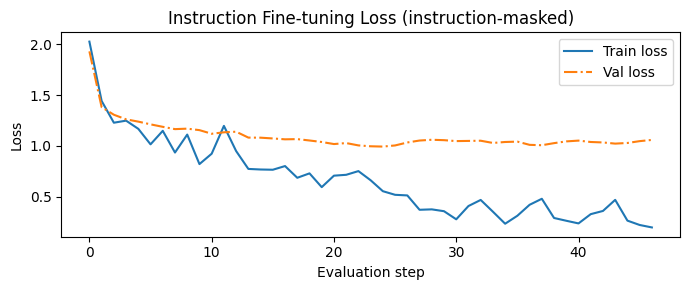

Instruction: Rewrite the sentence using a simile.
Input:       The car is very fast.
Expected:    The car is as fast as lightning.
Model:       The car is as fast as a cheetah.
------------------------------------------------------------
Instruction: What type of cloud is typically associated with thunderstorms?
Expected:    The type of cloud typically associated with thunderstorms is cumulonimbus.
Model:       The type of cloud associated with thunderstorms is a cumulus cloud.
------------------------------------------------------------
Instruction: Name the author of 'Pride and Prejudice'.
Expected:    Jane Austen.
Model:       The author of 'Pride and Prejudice' is George Bernard Shaw.
------------------------------------------------------------


In [12]:
# ── Loss curves for the masked fine-tuning run ───────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(train_losses_ins, label="Train loss")
ax.plot(val_losses_ins,   label="Val loss", linestyle="-.")
ax.set_xlabel("Evaluation step"); ax.set_ylabel("Loss")
ax.set_title("Instruction Fine-tuning Loss (instruction-masked)")
ax.legend(); plt.tight_layout(); plt.show()

# ── Inspect a few test responses from the masked model ───────────────────────
# IMPORTANT: instruction masking also masks the "### Response:\n" header, so the
# masked model was never trained to GENERATE that header on its own -- it only
# learned to produce the answer *after* it. So at inference we must feed the
# prompt INCLUDING "\n\n### Response:\n" and let the model continue with just the
# answer. (Feeding the header explicitly is the standard Alpaca convention and
# works for the unmasked baseline too.) Without this, the masked model emits EOS
# immediately and you get empty responses.
ins_model.eval()
for entry in test_data[:3]:
    prompt = format_input(entry) + "\n\n### Response:\n"
    token_ids = generate(
        ins_model, text_to_token_ids(prompt, tokenizer).to(device),
        max_new_tokens=100, context_size=INS_CONFIG["context_length"],
        temperature=0.0, eos_id=50256
    )
    response = token_ids_to_text(token_ids, tokenizer)[len(prompt):].strip()
    print(f"Instruction: {entry['instruction']}")
    if entry["input"]: print(f"Input:       {entry['input']}")
    print(f"Expected:    {entry['output']}")
    print(f"Model:       {response[:200]}")
    print("-" * 60)

In [11]:
# ── Baseline: identical setup, but WITHOUT instruction masking ───────────────
# Free the masked model first so two 355M models don't sit on the T4 at once.
# (We already captured the masked model's losses + sample outputs above.)
import gc
del ins_model, optimizer_ins
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

# Unmasked dataset: stores just the encoded full text (instruction + response)
class InstructionDatasetBaseline(Dataset):
    def __init__(self, data, tokenizer):
        self.encoded = [
            tokenizer.encode(format_input(e) + "\n\n### Response:\n" + e["output"])
            for e in data
        ]
    def __len__(self): return len(self.encoded)
    def __getitem__(self, idx): return self.encoded[idx]

# Original lab collate: masks ONLY padding (keeps one EOS), no instruction masking
def custom_collate_fn_baseline(batch, pad_token_id=50256, ignore_index=-100,
                               allowed_max_length=None, device="cpu"):
    max_len = max(len(ids) + 1 for ids in batch)
    inputs_lst, targets_lst = [], []
    for ids in batch:
        padded  = ids + [pad_token_id] * (max_len - len(ids))
        inputs  = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])
        pad_positions = (targets == pad_token_id).nonzero().squeeze(-1)
        if pad_positions.numel() > 1:
            targets[pad_positions[1:]] = ignore_index
        if allowed_max_length:
            inputs  = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]
        inputs_lst.append(inputs); targets_lst.append(targets)
    return torch.stack(inputs_lst).to(device), torch.stack(targets_lst).to(device)

base_collate = partial(custom_collate_fn_baseline, device=device, allowed_max_length=1024)
train_base_loader = DataLoader(InstructionDatasetBaseline(train_data, tokenizer),
                               batch_size=8, shuffle=True,  drop_last=True,  collate_fn=base_collate)
val_base_loader   = DataLoader(InstructionDatasetBaseline(val_data,   tokenizer),
                               batch_size=8, shuffle=False, drop_last=False, collate_fn=base_collate)

# Fresh pretrained model + identical training recipe (same seed, lr, epochs)
base_model = GPTModel(INS_CONFIG)
load_weights_into_gpt(base_model, params_m)
base_model.to(device)

torch.manual_seed(123)
optimizer_base = torch.optim.AdamW(base_model.parameters(), lr=5e-5, weight_decay=0.1)

t0 = time.time()
train_losses_base, val_losses_base, _ = train_instruction_model(
    base_model, train_base_loader, val_base_loader, optimizer_base, device,
    num_epochs=2, eval_freq=5, eval_iter=5,
    val_sample=val_data[0], tokenizer=tokenizer
)
print(f"\nUnmasked baseline training completed in {(time.time()-t0)/60:.1f} min")

Ep 1 Step 0000: train=2.637  val=2.626
Ep 1 Step 0005: train=1.174  val=1.103
Ep 1 Step 0010: train=0.872  val=0.944
Ep 1 Step 0015: train=0.857  val=0.906
Ep 1 Step 0020: train=0.776  val=0.881
Ep 1 Step 0025: train=0.754  val=0.859
Ep 1 Step 0030: train=0.799  val=0.836
Ep 1 Step 0035: train=0.714  val=0.808
Ep 1 Step 0040: train=0.672  val=0.806
Ep 1 Step 0045: train=0.633  val=0.789
Ep 1 Step 0050: train=0.663  val=0.783
Ep 1 Step 0055: train=0.760  val=0.763
Ep 1 Step 0060: train=0.719  val=0.743
Ep 1 Step 0065: train=0.653  val=0.735
Ep 1 Step 0070: train=0.533  val=0.729
Ep 1 Step 0075: train=0.568  val=0.729
Ep 1 Step 0080: train=0.604  val=0.725
Ep 1 Step 0085: train=0.509  val=0.710
Ep 1 Step 0090: train=0.563  val=0.691
Ep 1 Step 0095: train=0.502  val=0.681
Ep 1 Step 0100: train=0.504  val=0.677
Ep 1 Step 0105: train=0.565  val=0.670
Ep 1 Step 0110: train=0.554  val=0.666
Ep 1 Step 0115: train=0.508  val=0.663
  Sample response: The meal is prepared every day by the chef...

Response-only val loss  |  masked: 1.059   unmasked: 0.988
(lower = better; this is the fair comparison since both are scored on response tokens only)



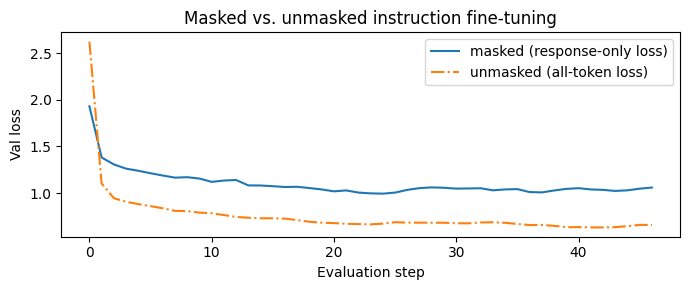

Instruction: Rewrite the sentence using a simile.
Input:       The car is very fast.
Expected:    The car is as fast as lightning.
Unmasked:    The car is as fast as a bullet.
------------------------------------------------------------
Instruction: What type of cloud is typically associated with thunderstorms?
Expected:    The type of cloud typically associated with thunderstorms is cumulonimbus.
Unmasked:    The type of cloud associated with thunderstorms is a cumulus cloud.
------------------------------------------------------------
Instruction: Name the author of 'Pride and Prejudice'.
Expected:    Jane Austen.
Unmasked:    The author of 'Pride and Prejudice' is Jane Austen.
------------------------------------------------------------


In [12]:
# ── Side-by-side comparison ──────────────────────────────────────────────────
# Fair, apples-to-apples metric: RESPONSE-ONLY validation loss for both models.
# val_ins_loader is the masked loader, so loss over it ignores instruction tokens.
# The masked model's response-only loss is just its final training val loss.
masked_resp_val = val_losses_ins[-1]
base_resp_val   = calc_loss_loader_ins(val_ins_loader, base_model, device)
print(f"Response-only val loss  |  masked: {masked_resp_val:.3f}   unmasked: {base_resp_val:.3f}")
print("(lower = better; this is the fair comparison since both are scored on response tokens only)\n")

# Loss curves -- note each curve is plotted against its OWN training objective
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(val_losses_ins,  label="masked (response-only loss)")
ax.plot(val_losses_base, label="unmasked (all-token loss)", linestyle="-.")
ax.set_xlabel("Evaluation step"); ax.set_ylabel("Val loss")
ax.set_title("Masked vs. unmasked instruction fine-tuning")
ax.legend(); plt.tight_layout(); plt.show()

# Sample responses from the UNMASKED baseline (compare to the masked ones above).
# Use the SAME header-inclusive prompt as the masked model so the two are decoded
# identically (the baseline also learned to emit the header, so either works).
base_model.eval()
for entry in test_data[:3]:
    prompt = format_input(entry) + "\n\n### Response:\n"
    ids = generate(base_model, text_to_token_ids(prompt, tokenizer).to(device),
                   max_new_tokens=100, context_size=INS_CONFIG["context_length"],
                   temperature=0.0, eos_id=50256)
    resp = token_ids_to_text(ids, tokenizer)[len(prompt):].strip()
    print(f"Instruction: {entry['instruction']}")
    if entry["input"]: print(f"Input:       {entry['input']}")
    print(f"Expected:    {entry['output']}")
    print(f"Unmasked:    {resp[:200]}")
    print("-" * 60)

**Exercise 3 — Applying instruction fine-tuning to congressional speeches**

We have a dataset of 28,000+ congressional floor speeches with party and date metadata. Design an instruction dataset from this corpus. For example:

- Instruction: `"Summarize this Democratic speech in one sentence."`
- Input: `[speech text]`
- Output: `[your summary]`

Or more interestingly:

- Instruction: `"What policy does this speech advocate for?"`
- Input: `[speech text]`
- Output: `[policy label]`

Sketch (in markdown) how you would construct `instruction-data.json` entries from the `us_congress_speeches_sample.csv` file. What would you use as the `output` field? What are the tradeoffs of different designs?

In [13]:
# ── Exercise 3: build an instruction dataset from the congressional speeches ──
# The CSV columns are: date, text, speaker_bioguide, chamber, party, doc_clean.
# Key idea: party/chamber are REAL labels already in the data, so we can build a
# reliable instruction dataset for free. (Summaries would have no ground truth --
# see the markdown sketch above for that trade-off.)
import pandas as pd, json, os

CSV = "us_congress_speeches_sample.csv"
# On Colab: upload this course file via the Files panel (or mount Google Drive).
assert os.path.exists(CSV), f"Upload {CSV} to the Colab session first (Files -> Upload)."

# Read only the columns we need
df = pd.read_csv(CSV, usecols=["date", "text", "party", "chamber"])
df = df.dropna(subset=["text", "party"])
df["text"] = df["text"].astype(str).str.strip()
df = df[df["party"].isin(["Democrat", "Republican"])]      # focus on the two major parties
df = df[df["text"].str.len().between(200, 2000)]           # drop fragments / over-long speeches

# Keep prompts within the model's context window by clipping the speech text
def clip(t, n=1200):
    return (t[:n].rsplit(" ", 1)[0] + " ...") if len(t) > n else t

# Design A — PARTY classification (the label exists, so output is reliable)
def make_party_entry(row):
    return {
        "instruction": ("Identify the political party of the member of Congress who gave this "
                        "floor speech. Answer with a single word: Democrat or Republican."),
        "input":  clip(row["text"]),
        "output": row["party"],
    }

# Balance the two classes so the model can't win by always predicting the majority label
n_per = 1500
balanced = pd.concat([
    df[df.party == "Democrat"].sample(n_per, random_state=0),
    df[df.party == "Republican"].sample(n_per, random_state=0),
]).sample(frac=1, random_state=0)   # shuffle

entries = [make_party_entry(r) for _, r in balanced.iterrows()]

with open("instruction-data-congress.json", "w") as f:
    json.dump(entries, f, indent=2)

print(f"Built {len(entries)} entries  ->  instruction-data-congress.json")
print("\nExample entry:")
print(json.dumps(entries[0], indent=2)[:700])

# To fine-tune on this, reuse the Exercise-2 pipeline:
#   data = entries
#   train_data, test_data, val_data = <re-split as before>
#   train_ds = InstructionDatasetWithMask(train_data, tokenizer)   # or the baseline dataset
#   ... then DataLoaders + train_instruction_model(...) exactly as above.

Built 3000 entries  ->  instruction-data-congress.json

Example entry:
{
  "instruction": "Identify the political party of the member of Congress who gave this floor speech. Answer with a single word: Democrat or Republican.",
  "input": "Mr. PADILLA. Mr. President, I rise to recognize the life of \nMr. Joe Lozano.\n  Joe ``Pinoy'' Lozano was born on December 26, 1934, in Pacoima, CA, \nas one of 10 children. Joe had every job you can imagine. He shined \nshoes and worked in the fields as a young boy. He joined the U.S. \nMarine Corp in 1954 and served during the Korean war as an infantryman.\n  After the service, he married the love of his life, Virginia. They \nwere married for 60 years and had 6 children, 21 grandchildren, 26 \ngreat-grandchildren, and 1 gre


In [15]:
# ── Fine-tune GPT-2 Medium on the congressional party-classification task ─────
# PREREQS (run these cells first, in this order):
#   • Exercise-2 solution cell  -> custom_collate_fn, InstructionDatasetWithMask, format_input
#   • "Train with instruction masking" cell -> train_instruction_model, calc_loss_loader_ins
#   • GPT-2 Medium loader cell   -> INS_CONFIG, params_m, load_weights_into_gpt
#   • Exercise-3 builder cell    -> entries
import gc, random
from functools import partial   # (also imported in the Exercise-2 cell; repeated here so this cell is runnable on its own)

# Friendly check so a missing prereq gives a clear message instead of a bare NameError
_missing = [name for name in
            ["custom_collate_fn", "InstructionDatasetWithMask", "train_instruction_model",
             "INS_CONFIG", "params_m", "load_weights_into_gpt", "entries"]
            if name not in globals()]
assert not _missing, f"Run the prereq cells first — missing: {_missing}"

# Re-split the congress entries into train / test / val (85 / 10 / 5)
random.seed(0)
random.shuffle(entries)
n = len(entries)
n_tr, n_te = int(0.85 * n), int(0.10 * n)
congress_train = entries[:n_tr]
congress_test  = entries[n_tr:n_tr + n_te]
congress_val   = entries[n_tr + n_te:]
print(f"train={len(congress_train)}  val={len(congress_val)}  test={len(congress_test)}")

# ── Free GPU memory from earlier runs ────────────────────────────────────────
# IMPORTANT: delete the earlier MODELS *and* their OPTIMIZERS. Moving a model to
# CPU does NOT free its optimizer's Adam state (~2.8 GB each), which is what caused
# the out-of-memory error. We fully delete them here; re-run the masked/baseline
# cells if you need those models again.
for _name in ["ins_model", "base_model", "optimizer_ins", "optimizer_base",
              "congress_model", "opt_c"]:
    if _name in globals():
        del globals()[_name]
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

# ── Masked datasets/loaders ──────────────────────────────────────────────────
# The output is a single label word, so masking the (long) speech prompt and
# training only on the label is the natural choice. Speeches are long, so attention
# memory (O(n^2) x batch) is large -> use a small batch. allowed_max_length=512
# caps the sequence; clipped speeches stay under it so the label is never truncated.
BATCH = 2   # raise to 4 if you have memory headroom; lower to 1 if you still OOM
c_collate = partial(custom_collate_fn, device=device, allowed_max_length=512)
c_train_loader = DataLoader(InstructionDatasetWithMask(congress_train, tokenizer),
                            batch_size=BATCH, shuffle=True,  drop_last=True,  collate_fn=c_collate)
c_val_loader   = DataLoader(InstructionDatasetWithMask(congress_val,   tokenizer),
                            batch_size=BATCH, shuffle=False, drop_last=False, collate_fn=c_collate)

# Fresh pretrained GPT-2 Medium (don't continue training an already-tuned model)
congress_model = GPTModel(INS_CONFIG)
load_weights_into_gpt(congress_model, params_m)
congress_model.to(device)

torch.manual_seed(123)
opt_c = torch.optim.AdamW(congress_model.parameters(), lr=5e-5, weight_decay=0.1)

t0 = time.time()
c_train_losses, c_val_losses, _ = train_instruction_model(
    congress_model, c_train_loader, c_val_loader, opt_c, device,
    num_epochs=2, eval_freq=50, eval_iter=5,
    val_sample=congress_val[0], tokenizer=tokenizer
)
print(f"\nCongress fine-tune completed in {(time.time()-t0)/60:.1f} min")

train=2550  val=150  test=300


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 15.81 MiB is free. Including non-PyTorch memory, this process has 14.54 GiB memory in use. Of the allocated memory 14.36 GiB is allocated by PyTorch, and 57.06 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [1]:
# =============================================================================
# EXERCISE 3 — STANDALONE.  Restart the runtime, upload the CSV, run ONLY this cell.
# =============================================================================

# (0) Reduce CUDA fragmentation. MUST be set before torch initializes CUDA.
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# (1) Installs (tiktoken for the tokenizer; tensorflow is used by the GPT-2 downloader)
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "tiktoken"], check=True)

# (2) Imports
import json, time, random, gc, urllib.request
import numpy as np
import pandas as pd
import torch, torch.nn as nn, tiktoken
from torch.utils.data import Dataset, DataLoader
from functools import partial

tokenizer = tiktoken.get_encoding("gpt2")
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# (3) GPT-2 model definition (from the lab) ------------------------------------
class LayerNorm(nn.Module):
    def __init__(self, d):
        super().__init__(); self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(d)); self.shift = nn.Parameter(torch.zeros(d))
    def forward(self, x):
        m = x.mean(-1, keepdim=True); v = x.var(-1, keepdim=True, unbiased=False)
        return self.scale * (x - m) / torch.sqrt(v + self.eps) + self.shift

class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0/torch.pi)) * (x + 0.044715*x**3)))

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(nn.Linear(cfg["emb_dim"], 4*cfg["emb_dim"]), GELU(),
                                    nn.Linear(4*cfg["emb_dim"], cfg["emb_dim"]))
    def forward(self, x): return self.layers(x)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, ctx, dropout, n_heads, qkv_bias=False):
        super().__init__()
        self.n_heads = n_heads; self.head_dim = d_out // n_heads; self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out); self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(ctx, ctx), diagonal=1))
    def forward(self, x):
        b, n, _ = x.shape
        q = self.W_query(x).view(b, n, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.W_key(x).view(b, n, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.W_value(x).view(b, n, self.n_heads, self.head_dim).transpose(1, 2)
        scores = q @ k.transpose(2, 3)
        scores.masked_fill_(self.mask.bool()[:n, :n], -torch.inf)
        w = self.dropout(torch.softmax(scores / k.shape[-1]**0.5, dim=-1))
        return self.out_proj((w @ v).transpose(1, 2).contiguous().view(b, n, self.d_out))

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(cfg["emb_dim"], cfg["emb_dim"], cfg["context_length"],
                                      cfg["drop_rate"], cfg["n_heads"], cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"]); self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop = nn.Dropout(cfg["drop_rate"])
    def forward(self, x):
        x = x + self.drop(self.att(self.norm1(x)))
        x = x + self.drop(self.ff(self.norm2(x)))
        return x

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)
    def forward(self, idx):
        b, n = idx.shape
        x = self.tok_emb(idx) + self.pos_emb(torch.arange(n, device=idx.device))
        return self.out_head(self.final_norm(self.trf_blocks(self.drop_emb(x))))

def text_to_token_ids(t, tok): return torch.tensor(tok.encode(t, allowed_special={"<|endoftext|>"})).unsqueeze(0)
def token_ids_to_text(ids, tok): return tok.decode(ids.squeeze(0).tolist())

def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits = model(idx[:, -context_size:])[:, -1, :]
        if top_k is not None:
            top, _ = torch.topk(logits, top_k)
            logits = torch.where(logits < top[:, -1], torch.tensor(float("-inf")).to(logits.device), logits)
        if temperature > 0.0:
            idx_next = torch.multinomial(torch.softmax(logits/temperature, -1), 1)
        else:
            idx_next = torch.argmax(logits, -1, keepdim=True)
        if eos_id is not None and idx_next.item() == eos_id: break
        idx = torch.cat((idx, idx_next), 1)
    return idx

# (4) Load pretrained GPT-2 Medium (355M) -------------------------------------
if not os.path.exists("gpt_download.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/"
        "main/ch05/01_main-chapter-code/gpt_download.py", "gpt_download.py")
from gpt_download import download_and_load_gpt2

def load_weights_into_gpt(gpt, p):
    gpt.pos_emb.weight = nn.Parameter(torch.tensor(p["wpe"]))
    gpt.tok_emb.weight = nn.Parameter(torch.tensor(p["wte"]))
    for b, blk in enumerate(gpt.trf_blocks):
        q, k, v = np.split(p["blocks"][b]["attn"]["c_attn"]["w"], 3, -1)
        blk.att.W_query.weight = nn.Parameter(torch.tensor(q).T)
        blk.att.W_key.weight   = nn.Parameter(torch.tensor(k).T)
        blk.att.W_value.weight = nn.Parameter(torch.tensor(v).T)
        qb, kb, vb = np.split(p["blocks"][b]["attn"]["c_attn"]["b"], 3)
        blk.att.W_query.bias = nn.Parameter(torch.tensor(qb))
        blk.att.W_key.bias   = nn.Parameter(torch.tensor(kb))
        blk.att.W_value.bias = nn.Parameter(torch.tensor(vb))
        blk.att.out_proj.weight = nn.Parameter(torch.tensor(p["blocks"][b]["attn"]["c_proj"]["w"]).T)
        blk.att.out_proj.bias   = nn.Parameter(torch.tensor(p["blocks"][b]["attn"]["c_proj"]["b"]))
        blk.ff.layers[0].weight = nn.Parameter(torch.tensor(p["blocks"][b]["mlp"]["c_fc"]["w"]).T)
        blk.ff.layers[0].bias   = nn.Parameter(torch.tensor(p["blocks"][b]["mlp"]["c_fc"]["b"]))
        blk.ff.layers[2].weight = nn.Parameter(torch.tensor(p["blocks"][b]["mlp"]["c_proj"]["w"]).T)
        blk.ff.layers[2].bias   = nn.Parameter(torch.tensor(p["blocks"][b]["mlp"]["c_proj"]["b"]))
        blk.norm1.scale = nn.Parameter(torch.tensor(p["blocks"][b]["ln_1"]["g"]))
        blk.norm1.shift = nn.Parameter(torch.tensor(p["blocks"][b]["ln_1"]["b"]))
        blk.norm2.scale = nn.Parameter(torch.tensor(p["blocks"][b]["ln_2"]["g"]))
        blk.norm2.shift = nn.Parameter(torch.tensor(p["blocks"][b]["ln_2"]["b"]))
    gpt.final_norm.scale = nn.Parameter(torch.tensor(p["g"]))
    gpt.final_norm.shift = nn.Parameter(torch.tensor(p["b"]))
    gpt.out_head.weight  = nn.Parameter(torch.tensor(p["wte"]))

INS_CONFIG = {"vocab_size": 50257, "context_length": 1024, "emb_dim": 1024,
              "n_heads": 16, "n_layers": 24, "drop_rate": 0.0, "qkv_bias": True}
_, params_m = download_and_load_gpt2(model_size="355M", models_dir="gpt2")
print("GPT-2 Medium loaded ✓")

# (5) Instruction-masking dataset + collate + training loop -------------------
def format_input(e):
    txt = ("Below is an instruction that describes a task. Write a response that "
           "appropriately completes the request.\n\n### Instruction:\n" + e["instruction"])
    return txt + (f"\n\n### Input:\n{e['input']}" if e["input"] else "")

class InstructionDatasetWithMask(Dataset):
    def __init__(self, data, tok):
        self.items = []
        for e in data:
            head = format_input(e) + "\n\n### Response:\n"
            self.items.append((tok.encode(head + e["output"]), len(tok.encode(head))))
    def __len__(self): return len(self.items)
    def __getitem__(self, i): return self.items[i]

def custom_collate_fn(batch, pad=50256, ignore=-100, max_len_cap=None, device="cpu"):
    L = max(len(ids) + 1 for ids, _ in batch)
    X, Y = [], []
    for ids, inst_len in batch:
        padded = ids + [pad] * (L - len(ids))
        x = torch.tensor(padded[:-1]); y = torch.tensor(padded[1:])
        pads = (y == pad).nonzero().squeeze(-1)
        if pads.numel() > 1: y[pads[1:]] = ignore     # keep one EOS, mask extra padding
        y[:inst_len - 1] = ignore                      # mask the instruction tokens
        if max_len_cap: x, y = x[:max_len_cap], y[:max_len_cap]
        X.append(x); Y.append(y)
    return torch.stack(X).to(device), torch.stack(Y).to(device)

def calc_loss(loader, model, device, nb=None):
    tot, n = 0., min(nb or len(loader), len(loader))
    for i, (xb, yb) in enumerate(loader):
        if i >= n: break
        xb, yb = xb.to(device), yb.to(device)
        tot += torch.nn.functional.cross_entropy(model(xb).flatten(0,1), yb.flatten(), ignore_index=-100).item()
    return tot / n

def train_model(model, tr, va, opt, device, epochs, eval_freq, eval_iter, val_sample):
    trL, vaL = [], []; step = -1
    for ep in range(epochs):
        model.train()
        for xb, yb in tr:
            opt.zero_grad(); xb, yb = xb.to(device), yb.to(device)
            loss = torch.nn.functional.cross_entropy(model(xb).flatten(0,1), yb.flatten(), ignore_index=-100)
            loss.backward(); opt.step(); step += 1
            if step % eval_freq == 0:
                tl, vl = calc_loss(tr, model, device, eval_iter), calc_loss(va, model, device, eval_iter)
                trL.append(tl); vaL.append(vl); print(f"Ep {ep+1} Step {step:04d}: train={tl:.3f} val={vl:.3f}")
        model.eval()
        prompt = format_input(val_sample) + "\n\n### Response:\n"
        ids = generate(model, text_to_token_ids(prompt, tokenizer).to(device), 10,
                       INS_CONFIG["context_length"], temperature=0.0, eos_id=50256)
        print("  sample:", token_ids_to_text(ids, tokenizer)[len(prompt):].strip()[:60])
        model.train()
    return trL, vaL

# (6) Build the congressional party-classification dataset from the CSV --------
CSV = "us_congress_speeches_sample.csv"
assert os.path.exists(CSV), f"Upload {CSV} to the Colab session first (Files -> Upload)."
df = pd.read_csv(CSV, usecols=["text", "party"]).dropna(subset=["text", "party"])
df["text"] = df["text"].astype(str).str.strip()
df = df[df["party"].isin(["Democrat", "Republican"])]
df = df[df["text"].str.len().between(200, 2000)]

def clip(t, n=1200): return (t[:n].rsplit(" ", 1)[0] + " ...") if len(t) > n else t
def make_entry(row):
    return {"instruction": ("Identify the political party of the member of Congress who gave this "
                            "floor speech. Answer with a single word: Democrat or Republican."),
            "input": clip(row["text"]), "output": row["party"]}

n_per = 1500
bal = pd.concat([df[df.party == "Democrat"].sample(n_per, random_state=0),
                 df[df.party == "Republican"].sample(n_per, random_state=0)]).sample(frac=1, random_state=0)
entries = [make_entry(r) for _, r in bal.iterrows()]
random.seed(0); random.shuffle(entries)
n = len(entries); n_tr, n_te = int(0.85*n), int(0.10*n)
train_data, test_data, val_data = entries[:n_tr], entries[n_tr:n_tr+n_te], entries[n_tr+n_te:]
print(f"dataset: train={len(train_data)} val={len(val_data)} test={len(test_data)}")

# (7) Fine-tune ----------------------------------------------------------------
BATCH = 4   # lower to 2/1 if you OOM
collate = partial(custom_collate_fn, device=device, max_len_cap=512)
tr_loader = DataLoader(InstructionDatasetWithMask(train_data, tokenizer), batch_size=BATCH,
                       shuffle=True, drop_last=True, collate_fn=collate)
va_loader = DataLoader(InstructionDatasetWithMask(val_data, tokenizer), batch_size=BATCH,
                       shuffle=False, drop_last=False, collate_fn=collate)

model = GPTModel(INS_CONFIG); load_weights_into_gpt(model, params_m); model.to(device)
torch.manual_seed(123)
opt = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
t0 = time.time()
train_model(model, tr_loader, va_loader, opt, device, epochs=2, eval_freq=50, eval_iter=5, val_sample=val_data[0])
print(f"fine-tune done in {(time.time()-t0)/60:.1f} min")

# (8) Test accuracy ------------------------------------------------------------
model.eval(); N = min(200, len(test_data)); correct = 0
for i, e in enumerate(test_data[:N]):
    prompt = format_input(e) + "\n\n### Response:\n"
    ids = generate(model, text_to_token_ids(prompt, tokenizer).to(device), 5,
                   INS_CONFIG["context_length"], temperature=0.0, eos_id=50256)
    gen = token_ids_to_text(ids, tokenizer)[len(prompt):].strip()
    pred = gen.split()[0].strip(".,!").capitalize() if gen.split() else ""
    correct += int(pred == e["output"])
    if i < 6:
        print(("✓" if pred == e["output"] else "✗"), f"pred={pred or '(empty)':11s} gold={e['output']}")
print(f"\nTest accuracy ({N} examples): {correct/N:.1%}   (50% = chance on balanced classes)")

Device: cuda
File already exists and is up-to-date: gpt2/355M/checkpoint
File already exists and is up-to-date: gpt2/355M/encoder.json
File already exists and is up-to-date: gpt2/355M/hparams.json
File already exists and is up-to-date: gpt2/355M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/355M/model.ckpt.index
File already exists and is up-to-date: gpt2/355M/model.ckpt.meta
File already exists and is up-to-date: gpt2/355M/vocab.bpe
GPT-2 Medium loaded ✓
dataset: train=2550 val=150 test=300
Ep 1 Step 0000: train=2.312 val=2.262
Ep 1 Step 0050: train=0.412 val=0.439
Ep 1 Step 0100: train=0.348 val=0.375
Ep 1 Step 0150: train=0.221 val=0.270
Ep 1 Step 0200: train=0.304 val=0.206
Ep 1 Step 0250: train=0.157 val=0.207
Ep 1 Step 0300: train=0.115 val=0.165
Ep 1 Step 0350: train=0.108 val=0.159
Ep 1 Step 0400: train=0.156 val=0.138
Ep 1 Step 0450: train=0.140 val=0.151
Ep 1 Step 0500: train=0.141 val=0.205
Ep 1 Step 0550: train=0.099 val=0.146
Ep 1 Step 0600: tr

In [2]:
# ── Show example speeches + the model's predictions ──────────────────────────
# Reuses the already-trained `model` and `test_data` from the cell above
# (no retraining needed). Prints the speech text, the true party, and the prediction.
model.eval()
for e in test_data[:10]:
    prompt = format_input(e) + "\n\n### Response:\n"
    ids = generate(model, text_to_token_ids(prompt, tokenizer).to(device), 5,
                   INS_CONFIG["context_length"], temperature=0.0, eos_id=50256)
    gen  = token_ids_to_text(ids, tokenizer)[len(prompt):].strip()
    pred = gen.split()[0].strip(".,!").capitalize() if gen.split() else "(empty)"
    flag = "✓" if pred == e["output"] else "✗"
    print(f"{flag}  predicted: {pred:11s} |  actual: {e['output']}")
    print(f"    speech: {e['input'][:240].strip()} ...")
    print("-" * 95)

✓  predicted: Democrat    |  actual: Democrat
    speech: Mr. CARDIN. Mr. Speaker, let me remind my friend that just a week 
ago, we approved over twice as much for the farm bill, without offsets.
  Mr. Speaker, it is my pleasure to yield 2 minutes to the gentleman 
from Wisconsin (Mr. Kind), one ...
-----------------------------------------------------------------------------------------------
✓  predicted: Republican  |  actual: Republican
    speech: Mr. CORNYN. Madam President, the Senator certainly is familiar with 
the rules of the Senate, which allow Senators to offer amendments to 
improve legislation once we get on it, but if the Democratic conference 
is going to prevent the Sena ...
-----------------------------------------------------------------------------------------------
✓  predicted: Democrat    |  actual: Democrat
    speech: Mr. DORGAN. Let me respond briefly to my friend from Oklahoma, and I 
will phrase it in the form of a question to the Senator from Nevada. 
The